[info] grid=(100,100,1500), h=(0.00707107,0.00707107,0.0133333), L=(0.7071067811865475,0.7071067811865475,20.0), dt=0.0002
[info] detector plane: z_det=19.9866657257 (index k=1499)
[info] Gaussian comparison params: z0=10.0, sigma_z=0.5, k0=1.0
[info] FIRST arrivals: 13487 / 100000 (13.5%) [ALL particles]
[info] Loaded probability data: Nt=2993
[flux ] ∫(-dP/dt) dt = 0.130305 ; P(0)-P(T) = 0.130312
[rmat] restricted mean μ*(T_final) from survival = 37.052188
[flux ] A(T_final) from flux/survival             = 0.130349
[cond ] τ̄_cond^T from Eq. (80)                  = 17.385257
[rmat] clipped-time estimator mean min(τ,T_final) = 36.928978
[rmat] SD[min(τ,T_final)]                         = 8.93248
[rmat] SE[μ*(T_final)] from clipped times        = 0.028247
[rmat] 95% CI half-width for μ*(T_final)         = 0.0553641
[rmat] survival vs clipped estimator Δ          = +1.232095e-01
[theory] ∫ρ_free_Gauss dt (unscaled) = 0.702137
[hist ] detection fraction via histogram = 0.134870 (~ 0.134

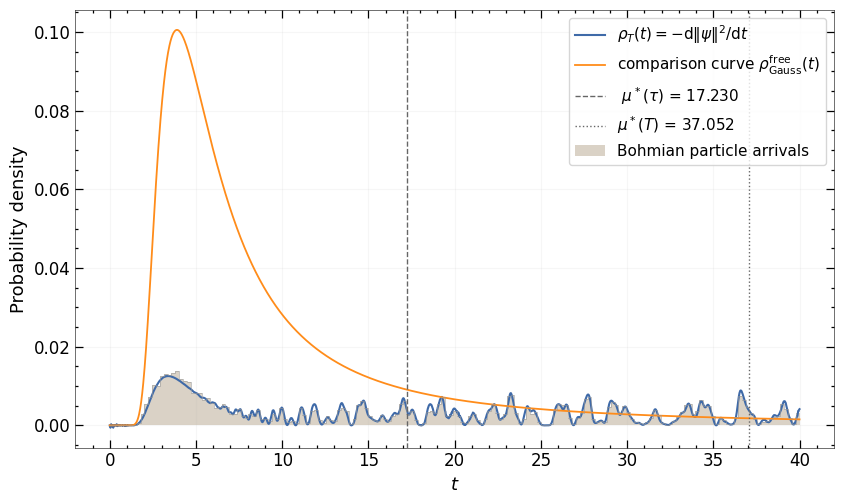

/tmp/ipykernel_202667/4289772077.py:522: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig2.tight_layout()
/tmp/ipykernel_202667/4289772077.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig2.savefig(out2, dpi=200)


[info] saved trajectories plot → /scratch/hpc-prf-gasqd/hpcaljo1/workspace0/3D/2038(2).Spin_Gauss_DirichletABC_theta=pi6+C_Omega=200_L=20_k0=1_sigma=0.5_T=40/sample_traj_z_vs_t.png


/pc2/groups/hpc-prf-gasqd/hpcaljo1/pyenvs/tdse-cupy-otus-py311/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/pc2/groups/hpc-prf-gasqd/hpcaljo1/pyenvs/tdse-cupy-otus-py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


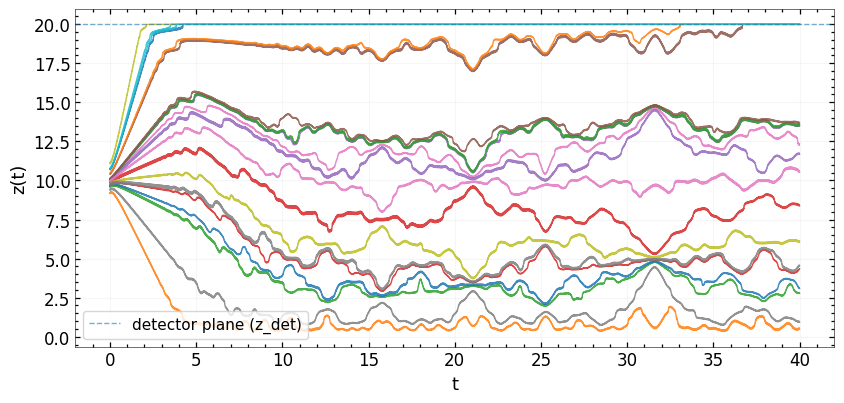

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Unified arrival-time & trajectory postprocessing
(adapted to the Gaussian solver 617SpinorXY_Gauss_Bohm_DirichletABC.py)

What this script computes:
  - Survival S(t) = ||ψ(t)||^2 / ||ψ(0)||^2 from total_probs.npy
  - Restricted Mean Arrival Time (RMAT):
        μ*(T_final) = ∫_0^T S(t) dt
  - Correct Monte-Carlo SE for μ*(T_final) from clipped times:
        Y_i = min(τ_i, T_final),   μ*_MC = mean(Y_i),
        SE[μ*(T_final)] = std(Y_i)/sqrt(M)
  - Finite-horizon conditional Bohmian mean:
        τ̄_cond^T = E[τ | τ <= T_final]
    together with its usual SE over the conditioned Bohmian samples
  - Flux-based finite-horizon conditional mean from Sec. 5.5.1 / Eq. (80):
        τ̄_cond^T = (μ*(T_final) - T_final)/A(T_final) + T_final
    where A(T_final) = ∫_0^T g(t) dt and g(t) = max(-dS/dt, 0)

Auto-detects whether you're using the FULL population or the SELECTED subset.

Reads (some optional):
  - constants.npz
  - bohm_t_hit.npy                  (FULL)             OR bohm_t_hit_selected.npy (SELECTED)
  - bohm_arrived_mask.npy           (FULL)             OR bohm_arrived_mask_selected.npy (SELECTED)
  - prob_times.npy, total_probs.npy (for flux + RMAT)
  - bohmian_traj_selected.npy       (optional, for plotting a few trajectories)
  - bohm_times.npy                  (optional, time axis for trajectories)

Outputs:
  - combined_arrival2.png (and optional .pdf)
  - sample_traj_z_vs_t.png          (if trajectories are available)
  - arrival_stats_summary.npz       (for later collection across many ω runs)
  - arrival_stats_summary.txt       (human-readable summary)
  - console summary
"""

from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# =========================
STYLE = {
    # colors
    "color_flux": "#3F6AA8",   # dark blue
    "color_free": "#FF8C1A",   # orange
    "color_hist": "#D6CEC0",   # sand / beige
    "color_mean": "0.4",       # dashed mean (gray)

    # line widths / alpha
    "lw_flux": 1.5,
    "lw_free": 1.3,
    "lw_mean": 1.0,
    "hist_alpha": 0.9,

    # optional thin square-outline on top of bars
    "hist_step_overlay": True,
    "hist_step_lw": 0.4,
    "hist_step_color": "0.6",

    # ticks
    "tick_len_major": 6,
    "tick_len_minor": 2.5,

    # figure
    "figsize_main": (8.6, 5.2),
    "dpi_png": 300,
    "save_pdf": True,

    # axes/ticks thickness
    "axes_linewidth": 0.4,
    "tick_width": 0.9,
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "savefig.bbox": "tight",
})

# -------------------- I/O and constants --------------------
base = Path(os.getcwd())
C = np.load(base / "constants.npz")

Nx, Ny, Nz = int(C["Nx"]), int(C["Ny"]), int(C["Nz"])
hx, hy, hz = float(C["hx"]), float(C["hy"]), float(C["hz"])
Lx, Ly, Lz = float(C["Lx"]), float(C["Ly"]), float(C["Lz"])
dt = float(C["dt"])
Mpart_const = int(C["Mpart"]) if "Mpart" in C else None
omega_val = float(C["omega"]) if "omega" in C else np.nan

print(f"[info] grid=({Nx},{Ny},{Nz}), h=({hx:.6g},{hy:.6g},{hz:.6g}), "
      f"L=({Lx},{Ly},{Lz}), dt={dt}")

# -------------------- Detector plane (prefer stored value) ----------
z_det = float(C["z_det"]) if "z_det" in C else (Lz - hz)
k_det = Nz - 1
print(f"[info] detector plane: z_det={z_det:.12g} (index k={k_det})")

# -------------------- Gaussian free comparison curve ----------------
# For the Gaussian solver:
#   psi_z(z,0) ∝ exp(-(z-z0)^2/(2 sigma_z^2)) * exp(i k0 (z-z0))
# in units m = ħ = 1.
#
# We use the free 1D current at z = z_det as the comparison curve.
# The transverse factor is normalized and separable, so the plane-integrated
# comparison reduces to the longitudinal current.

have_gaussian_params = all(k in C for k in ["z0", "sigma_z", "k0"])
z0_gauss    = float(C["z0"])      if "z0"      in C else np.nan
sigma_gauss = float(C["sigma_z"]) if "sigma_z" in C else np.nan
k0_gauss    = float(C["k0"])      if "k0"      in C else np.nan

if have_gaussian_params:
    print(f"[info] Gaussian comparison params: z0={z0_gauss}, sigma_z={sigma_gauss}, k0={k0_gauss}")
else:
    print("[warn ] Gaussian parameters (z0, sigma_z, k0) not found in constants.npz; "
          "comparison curve will be skipped.")

def rho_free_gaussian(z_det, taus, z0, sigma, k0):
    """
    Free 1D probability current j(z_det,t) for the initial packet
        psi(z,0) ∝ exp(-(z-z0)^2/(2 sigma^2)) * exp(i k0 (z-z0))
    in units m = ħ = 1.
    """
    taus = np.asarray(taus, dtype=np.float64)
    out = np.zeros_like(taus, dtype=np.float64)

    mask = taus > 0.0
    if not np.any(mask):
        return out

    t = taus[mask]

    # center relative to detector
    xi = z_det - z0 - k0 * t

    # density at detector
    spread = 1.0 + (t / sigma**2)**2
    rho = np.exp(-(xi**2) / (sigma**2 * spread)) / (np.sqrt(np.pi) * sigma * np.sqrt(spread))

    # free Gaussian velocity field at detector
    vz = k0 + (t * xi) / (sigma**4 + t**2)

    out[mask] = rho * vz
    return out

# -------------------- Load arrivals (auto: FULL vs SELECTED) -------
hit_full    = base / "bohm_t_hit.npy"
mask_full   = base / "bohm_arrived_mask.npy"
hit_sel     = base / "bohm_t_hit_selected.npy"
mask_sel    = base / "bohm_arrived_mask_selected.npy"
traj_sel_f  = base / "bohmian_traj_selected.npy"
times_path  = base / "bohm_times.npy"

use_full     = hit_full.exists() and mask_full.exists()
use_selected = hit_sel.exists() and mask_sel.exists()

if not (use_full or use_selected):
    raise FileNotFoundError(
        "Missing arrivals: need either (bohm_t_hit.npy & bohm_arrived_mask.npy) "
        "OR (bohm_t_hit_selected.npy & bohm_arrived_mask_selected.npy)."
    )

if use_full:
    t_hit   = np.load(hit_full)
    arrived = np.load(mask_full).astype(bool)
    subset_note = "[ALL particles]"
else:
    t_hit   = np.load(hit_sel)
    arrived = np.load(mask_sel).astype(bool)
    subset_note = "[SELECTED subset]"

if len(t_hit) != len(arrived):
    raise RuntimeError("t_hit and arrived_mask have different lengths.")

M_loaded = len(t_hit)
Mpart = M_loaded

if (Mpart_const is not None) and (Mpart_const != M_loaded):
    print(f"[warn ] constants.npz Mpart={Mpart_const} but loaded {M_loaded} entries {subset_note}; "
          f"using Mpart={M_loaded} for statistics/histogram normalization.")

first_tau = t_hit[arrived & np.isfinite(t_hit)]
arriv_frac = first_tau.size / float(Mpart)
print(f"[info] FIRST arrivals: {first_tau.size} / {Mpart} ({arriv_frac:.1%}) {subset_note}")

# -------------------- Load probability data for flux & RMAT -------
prob_times   = None
total_probs  = None
flux_density = None
taus_theory  = None

mu_rmat      = np.nan
mu_star_mc   = np.nan
sd_mu_star   = np.nan
se_mu_star   = np.nan
ci95_mu_star = np.nan

A_T_flux      = np.nan
tau_cond_flux = np.nan

int_flux  = np.nan
drop_prob = np.nan
T_final_data = np.nan

try:
    prob_times  = np.load(base / "prob_times.npy")
    total_probs = np.load(base / "total_probs.npy")
    n = min(len(prob_times), len(total_probs))
    prob_times  = prob_times[:n]
    total_probs = total_probs[:n]
    print(f"[info] Loaded probability data: Nt={n}")

    # numerical flux density ρ_T(t) = -d||ψ||²/dt
    dP_dt = np.gradient(total_probs, prob_times)
    flux_density = -dP_dt
    int_flux = simpson(flux_density, x=prob_times)
    drop_prob = total_probs[0] - total_probs[-1]
    print(f"[flux ] ∫(-dP/dt) dt = {int_flux:.6f} ; P(0)-P(T) = {drop_prob:.6f}")

    # restricted mean from survival
    S = total_probs / total_probs[0]
    T_final_data = float(prob_times[-1])
    mu_rmat = simpson(S, x=prob_times)
    print(f"[rmat] restricted mean μ*(T_final) from survival = {mu_rmat:.6f}")

    # finite-horizon conditional mean from survival/flux
    g_surv = np.maximum(-np.gradient(S, prob_times), 0.0)
    A_T_flux = simpson(g_surv, x=prob_times)

    if A_T_flux > 0:
        tau_cond_flux = (mu_rmat - T_final_data) / A_T_flux + T_final_data
    else:
        tau_cond_flux = np.nan

    print(f"[flux ] A(T_final) from flux/survival             = {A_T_flux:.6f}")
    print(f"[cond ] τ̄_cond^T from Eq. (80)                  = {tau_cond_flux:.6f}")

    # clipped-time estimator of μ*(T_final)
    y_clip = np.full(Mpart, T_final_data, dtype=np.float64)
    valid_hit = arrived & np.isfinite(t_hit)
    y_clip[valid_hit] = np.minimum(t_hit[valid_hit], T_final_data)

    mu_star_mc = np.mean(y_clip)

    if Mpart > 1:
        sd_mu_star = np.std(y_clip, ddof=1)
        se_mu_star = sd_mu_star / np.sqrt(Mpart)
        ci95_mu_star = 1.96 * se_mu_star
    else:
        sd_mu_star = np.nan
        se_mu_star = np.nan
        ci95_mu_star = np.nan

    print(f"[rmat] clipped-time estimator mean min(τ,T_final) = {mu_star_mc:.6f}")
    print(f"[rmat] SD[min(τ,T_final)]                         = {sd_mu_star:.6g}")
    print(f"[rmat] SE[μ*(T_final)] from clipped times        = {se_mu_star:.6g}")
    print(f"[rmat] 95% CI half-width for μ*(T_final)         = {ci95_mu_star:.6g}")

    if np.isfinite(mu_rmat):
        print(f"[rmat] survival vs clipped estimator Δ          = {mu_rmat - mu_star_mc:+.6e}")

    taus_theory = prob_times.copy()

except FileNotFoundError:
    print("[warn ] prob_times.npy / total_probs.npy not found; skipping flux and RMAT.")

# -------------------- Gaussian comparison curve --------------------
if (taus_theory is not None) and have_gaussian_params:
    pi_theory = rho_free_gaussian(
        z_det=z_det,
        taus=taus_theory,
        z0=z0_gauss,
        sigma=sigma_gauss,
        k0=k0_gauss,
    )
    int_th = simpson(pi_theory, x=taus_theory)
    print(f"[theory] ∫ρ_free_Gauss dt (unscaled) = {int_th:.6g}")
else:
    pi_theory = None
    int_th = np.nan

# -------------------- Histogram (per launched of loaded set) ------
if prob_times is not None:
    tmin, tmax = taus_theory[0], taus_theory[-1]
else:
    tmin, tmax = (np.nanmin(first_tau), np.nanmax(first_tau)) if first_tau.size else (0.0, 1.0)

data = first_tau[(first_tau >= tmin) & (first_tau <= tmax)]
nbins = 180
bins = np.linspace(tmin, tmax, nbins)
counts, edges = np.histogram(data, bins=bins)
bw = edges[1] - edges[0]
centers = 0.5 * (edges[:-1] + edges[1:])
hist_per_launched = counts / (Mpart * bw)
det_frac_hist = counts.sum() / float(Mpart)
print(f"[hist ] detection fraction via histogram = {det_frac_hist:.6f} (~ {arriv_frac:.6f})")

# -------------------- Bohmian finite-horizon conditional mean -----
def mean_from_samples(taus):
    if len(taus) == 0:
        return np.nan, np.nan, 0
    mu = np.mean(taus)
    se = np.std(taus, ddof=1) / np.sqrt(len(taus)) if len(taus) > 1 else np.nan
    return mu, se, len(taus)

if np.isfinite(T_final_data):
    tau_cond_bohm = t_hit[arrived & np.isfinite(t_hit) & (t_hit <= T_final_data)]
else:
    tau_cond_bohm = first_tau.copy()

mu_sample, se_sample, N_sample = mean_from_samples(tau_cond_bohm)
A_T_bohm = N_sample / float(Mpart) if Mpart > 0 else np.nan

print("\n===== Arrival-time summary =====")
print(f"Bohmian τ̄_cond^T = E[τ | τ <= T_final]         = {mu_sample:.6g} [SE={se_sample:.3g}, N={N_sample}] {subset_note}")
print(f"Bohmian A(T_final) = P(τ <= T_final)            = {A_T_bohm:.6f}")
if np.isfinite(mu_rmat):
    print(f"μ*(T_final) from survival                       = {mu_rmat:.6g}")
if np.isfinite(tau_cond_flux):
    print(f"Flux-based τ̄_cond^T from Eq. (80)              = {tau_cond_flux:.6g}")
if np.isfinite(mu_star_mc):
    print(f"μ*(T_final) from clipped times                  = {mu_star_mc:.6g} [SE={se_mu_star:.3g}, SD={sd_mu_star:.3g}, M={Mpart}]")
print("================================\n")

# -------------------- Save summary for later multi-ω collection ---
summary_npz = base / "arrival_stats_summary.npz"
np.savez(
    summary_npz,
    omega=omega_val,
    z_det=z_det,
    T_final=T_final_data,
    Mpart=Mpart,
    N_detected=N_sample,
    N_detected_by_T=N_sample,
    arrival_fraction=arriv_frac,
    arrival_fraction_by_T=A_T_bohm,
    hist_detection_fraction=det_frac_hist,
    flux_integral=int_flux,
    prob_drop=drop_prob,
    theory_integral=int_th,
    A_T_flux=A_T_flux,
    tau_cond_flux=tau_cond_flux,
    mu_cond=mu_sample,
    se_cond=se_sample,
    mu_rmat_survival=mu_rmat,
    mu_star_clip=mu_star_mc,
    sd_mu_star_clip=sd_mu_star,
    se_mu_star_clip=se_mu_star,
    ci95_mu_star_clip=ci95_mu_star,
    is_full_population=bool(use_full),
)

summary_txt = base / "arrival_stats_summary.txt"
with open(summary_txt, "w", encoding="utf-8") as f:
    f.write("Arrival-time summary\n")
    f.write("====================\n")
    f.write(f"omega                     = {omega_val}\n")
    f.write(f"subset                    = {subset_note}\n")
    f.write(f"z_det                     = {z_det:.12g}\n")
    f.write(f"T_final                   = {T_final_data:.12g}\n")
    f.write(f"Mpart_loaded              = {Mpart}\n")
    f.write(f"N_detected                = {N_sample}\n")
    f.write(f"N_detected_by_T           = {N_sample}\n")
    f.write(f"arrival_fraction          = {arriv_frac:.12g}\n")
    f.write(f"arrival_fraction_by_T     = {A_T_bohm:.12g}\n")
    f.write(f"hist_detection_fraction   = {det_frac_hist:.12g}\n")
    f.write(f"flux_integral             = {int_flux:.12g}\n")
    f.write(f"probability_drop          = {drop_prob:.12g}\n")
    f.write(f"theory_integral_unscaled  = {int_th:.12g}\n")
    f.write(f"A_T_flux                  = {A_T_flux:.12g}\n")
    f.write(f"tau_cond_flux             = {tau_cond_flux:.12g}\n")
    f.write(f"mu_conditional            = {mu_sample:.12g}\n")
    f.write(f"se_conditional            = {se_sample:.12g}\n")
    f.write(f"mu_rmat_survival          = {mu_rmat:.12g}\n")
    f.write(f"mu_star_clipped           = {mu_star_mc:.12g}\n")
    f.write(f"sd_mu_star_clipped        = {sd_mu_star:.12g}\n")
    f.write(f"se_mu_star_clipped        = {se_mu_star:.12g}\n")
    f.write(f"ci95_mu_star_clipped      = {ci95_mu_star:.12g}\n")

print(f"[info] saved summary → {summary_npz.resolve()}")
print(f"[info] saved summary → {summary_txt.resolve()}")

# -------------------- Combined plot ------------------------------
fig, ax = plt.subplots(figsize=STYLE["figsize_main"])

for spine in ax.spines.values():
    spine.set_linewidth(STYLE["axes_linewidth"])
ax.tick_params(axis="both", which="both", width=STYLE["tick_width"])

handles = []
labels = []

# dark blue: ρ_T(t)
if (prob_times is not None) and (flux_density is not None):
    h_flux, = ax.plot(
        prob_times, flux_density,
        lw=STYLE["lw_flux"], color=STYLE["color_flux"],
        label=r'$\rho_T(t)=-\mathrm{d}\|\psi\|^2/\mathrm{d}t$'
    )
    handles.append(h_flux)
    labels.append(h_flux.get_label())

# orange: Gaussian free comparison curve
if (taus_theory is not None) and (pi_theory is not None):
    h_free, = ax.plot(
        taus_theory, pi_theory,
        lw=STYLE["lw_free"], color=STYLE["color_free"],
        label=r'comparison curve $\rho^{\mathrm{free}}_{\mathrm{Gauss}}(t)$'
    )
    handles.append(h_free)
    labels.append(h_free.get_label())

# sand / beige: Bohmian particle arrivals
h_hist = ax.bar(
    centers, hist_per_launched,
    width=bw, alpha=STYLE["hist_alpha"],
    color=STYLE["color_hist"], edgecolor="none",
    label='Bohmian particle arrivals'
)
handles.append(h_hist)
labels.append(h_hist.get_label())

if STYLE.get("hist_step_overlay", False):
    ax.step(
        edges[:-1], hist_per_launched,
        where="post",
        lw=STYLE["hist_step_lw"],
        color=STYLE["hist_step_color"],
        alpha=1.0,
        label=None
    )

# vertical line for finite-horizon conditional Bohmian mean
if np.isfinite(mu_sample):
    h_mean = ax.axvline(
        mu_sample,
        ls="--",
        lw=STYLE["lw_mean"],
        color=STYLE["color_mean"],
        label=rf' $\mu^*(\tau)$ = {mu_sample:.3f}'
    )
    handles.insert(max(0, len(handles) - 1), h_mean)
    labels.insert(max(0, len(labels) - 1), h_mean.get_label())

# vertical line for RMAT μ*(T)
if np.isfinite(mu_rmat):
    rmat_label = rf'$\mu^*(T)$ = {mu_rmat:.3f}'
    h_rmat = ax.axvline(
        mu_rmat,
        ls=":",
        lw=STYLE["lw_mean"],
        color=STYLE["color_mean"],
        label=rmat_label
    )
    handles.insert(max(0, len(handles) - 1), h_rmat)
    labels.insert(max(0, len(labels) - 1), h_rmat.get_label())

ax.set_xlabel(r'$t$')
ax.set_ylabel('Probability density')

ax.minorticks_on()
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.tick_params(axis="both", which="major", length=STYLE["tick_len_major"])
ax.tick_params(axis="both", which="minor", length=STYLE["tick_len_minor"])

ax.grid(True, alpha=0.1)
ax.legend(handles, labels, frameon=True)
fig.tight_layout()

out_png = base / "combined_arrival2.png"
fig.savefig(out_png, dpi=int(STYLE["dpi_png"]))
print(f"[info] saved combined → {out_png.resolve()}")

if STYLE["save_pdf"]:
    out_pdf = base / "combined_arrival2.pdf"
    fig.savefig(out_pdf)
    print(f"[info] saved combined → {out_pdf.resolve()}")

plt.show()
plt.close(fig)

# -------------------- Optional: plot a few saved trajectories ------
if traj_sel_f.exists():
    traj_sel = np.load(traj_sel_f)
    Ktraj = traj_sel.shape[1]
    take = min(200, Ktraj)
    idx_show = np.linspace(0, Ktraj - 1, take, dtype=int)

    if times_path.exists():
        tvec = np.load(times_path)
        if len(tvec) != traj_sel.shape[0]:
            tvec = np.arange(traj_sel.shape[0]) * dt
            print("[warn ] bohm_times length mismatch; using dt*step index for trajectories.")
    else:
        tvec = np.arange(traj_sel.shape[0]) * dt

    fig2, ax2 = plt.subplots(figsize=(8.6, 4.2))

    for spine in ax2.spines.values():
        spine.set_linewidth(STYLE["axes_linewidth"])
    ax2.tick_params(axis="both", which="both", width=STYLE["tick_width"])

    for j in idx_show:
        ax2.plot(tvec, traj_sel[:, j, 2], lw=1.0, alpha=0.85)

    ax2.axhline(z_det, ls='--', lw=1.0, alpha=0.6, label='detector plane (z_det)')
    ax2.set_xlabel('t')
    ax2.set_ylabel('z(t)')
    ax2.grid(True, alpha=0.1)
    ax2.legend()

    ax2.minorticks_on()
    ax2.tick_params(axis="both", which="both", direction="in", top=True, right=True)

    fig2.tight_layout()
    out2 = base / "sample_traj_z_vs_t.png"
    fig2.savefig(out2, dpi=200)
    print(f"[info] saved trajectories plot → {out2.resolve()}")
else:
    print("[info] No 'bohmian_traj_selected.npy' found; skipping trajectory plot.")

[info] Loaded: Lz=20.0, dt (saved)=0.001, Nt=724
[diag] area(numerical loss over saved times) ≈ 0.000013
[diag] area(theory over saved times)        ≈ 0.842048
[diag] theory peak ≈ 0.167114 at τ ≈ 5.666
[ok] Wrote plots to: /scratch/hpc-prf-gasqd/hpcaljo1/workspace0/3D/2040.Spin_Gauss_DirichletReflec_theta=0+C_Omega=1_L=20/plots_compare


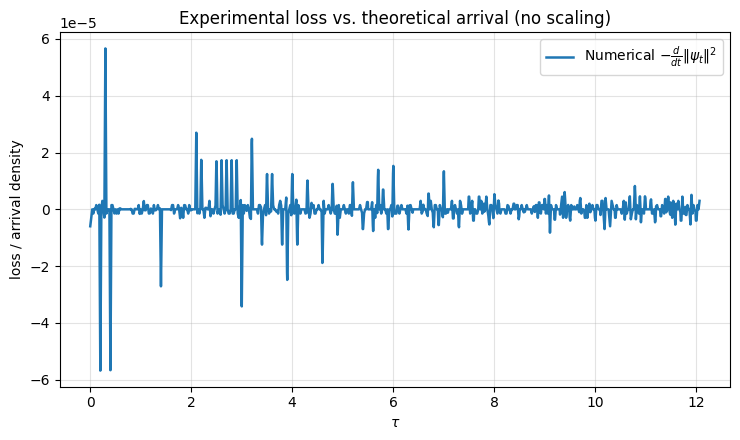

In [1]:
#!/usr/bin/env python3
"""
Automatic loader & overlay:
- Reads constants.npz, prob_times.npy, total_probs.npy from the current folder
- Plots total probability
- Computes numerical loss  = - d/dt ||psi_t||^2  (from saved series)
- Computes theory Pi_qf(tau) with L = Lz (from constants), slab 0<xi<1, sin(pi*xi)
- Overlays both curves on the SAME time grid (no scaling/normalizing)
- Saves PNGs in ./plots_compare
"""
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi
from scipy.integrate import simpson

# -------------------------- I/O setup --------------------------
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()

data_dir = script_dir
plot_dir = script_dir / "plots_compare"
plot_dir.mkdir(exist_ok=True)

# ----------------------- load saved data -----------------------
C = np.load(data_dir / "constants.npz")
Lz = float(C["Lz"])
dt_saved = float(C["dt"])

prob_times = np.load(data_dir / "prob_times.npy")          # shape (Nt,)
total_probs = np.load(data_dir / "total_probs.npy")        # shape (Nt,)
n = min(len(prob_times), len(total_probs))
prob_times = prob_times[:n]
total_probs = total_probs[:n]

print(f"[info] Loaded: Lz={Lz}, dt (saved)={dt_saved}, Nt={n}")

# ---------------- plot total probability -----------------------
plt.figure(figsize=(7,4))
plt.plot(prob_times, total_probs, lw=1.8, label="Total probability")
plt.xlabel("time")
plt.ylabel(r"$\|\psi_t\|^2$")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "total_probability_vs_time.png", dpi=240)
plt.close()

# --------------- numerical loss: - d/dt ||psi||^2 ---------------
# Use gradient to respect nonuniform time steps if any
dP_dt = np.gradient(total_probs, prob_times)
loss_num = -dP_dt   # THIS is your experimental loss curve

# --------------- theory Π_qf(τ): Eqs. (10–12,15) ---------------
def K(s, t):
    # i ψ_t = -(1/2) ψ_{zz}, ħ=m=1
    return (1/np.sqrt(2j*pi*t)) * np.exp(1j*s*s/(2*t))

def W_and_dWdz(L, t, nxi=4096):
    # slab 0<xi<1 with sin(pi*xi); method-of-images + chain rule
    xi = np.linspace(0.0, 1.0, nxi)
    w  = np.sin(pi*xi)
    K1 = K(L - xi, t)
    K2 = K(L + xi, t)
    W  = simpson(w*(K1 - K2), x=xi)
    dW = (1j/t) * simpson(w*((L - xi)*K1 - (L + xi)*K2), x=xi)
    return W, dW

def Pi_qf(L, taus):
    out = np.zeros_like(taus, dtype=float)
    for i, t in enumerate(taus):
        if t <= 0: 
            continue
        W, dW = W_and_dWdz(L, t)
        out[i] = 2*np.imag(np.conj(W)*dW)  # Eq. (15)
    return out

# IMPORTANT: we compute theory on the SAME time grid as your data
taus = prob_times.copy()
Pi_theory = Pi_qf(Lz, taus)

# --------------------------- overlay ---------------------------
plt.figure(figsize=(7.5,4.5))
plt.plot(taus, loss_num, lw=1.8, label=r"Numerical $-\frac{d}{dt}\|\psi_t\|^2$")
#plt.plot(taus, Pi_theory, lw=2.2, label=rf"Theory $\Pi_{{qf}}(\tau)$ (L={Lz:g})")
plt.xlabel(r"$\tau$")
plt.ylabel("loss / arrival density")
plt.title("Experimental loss vs. theoretical arrival (no scaling)")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "loss_vs_theory_raw.png", dpi=300)

# ------------------------ quick diagnostics --------------------
area_num = simpson(np.clip(loss_num,0,None), x=taus)
area_th  = simpson(np.clip(Pi_theory,0,None), x=taus)
peak_tau_th = taus[np.argmax(Pi_theory)]

peak_val_th = Pi_theory.max()
print(f"[diag] area(numerical loss over saved times) ≈ {area_num:.6f}")
print(f"[diag] area(theory over saved times)        ≈ {area_th:.6f}")
print(f"[diag] theory peak ≈ {peak_val_th:.6f} at τ ≈ {peak_tau_th:.3f}")
print(f"[ok] Wrote plots to: {plot_dir.resolve()}")

